<a href="https://colab.research.google.com/github/MiguelGonzalez197/Proyecto_IA-Ecomision/blob/Miguel/ProyectoEcomision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [14]:
# Librerias
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Cargar Dataset
dataset_path = "/content/drive/MyDrive/ProyectoIA-Ecomision/dataset"

img_size = (224, 224)
batch_size = 32

train_ds = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 104 files belonging to 3 classes.
Using 84 files for training.
Found 104 files belonging to 3 classes.
Using 20 files for validation.


In [ ]:
#Crear modelo con Transfer Learning
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # congelamos capas

model = models.Sequential([
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')  # 3 clases
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Compilar modelo
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Entrenar
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 25s 6s/step - accuracy: 0.3192 - loss: 1.4184 - val_accuracy: 0.6500 - val_loss: 0.7597
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.7779 - loss: 0.4502 - val_accuracy: 0.9000 - val_loss: 0.2470
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step - accuracy: 0.8860 - loss: 0.2657 - val_accuracy: 0.9500 - val_loss: 0.1664
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 1.0000 - loss: 0.1175 - val_accuracy: 0.9500 - val_loss: 0.1821
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step - accuracy: 1.0000 - loss: 0.0590 - val_accuracy: 0.9000 - val_loss: 0.2269
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 1.0000 - loss: 0.0499 - val_accuracy: 0.9000 - val_loss: 0.2140
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 1.0000 - loss: 0.0277 - val_accuracy: 0.9500 - val_loss: 0.1715
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 1.0000 - loss: 0.0140 - val_accuracy: 0.9500 - val_loss: 0.1412
Epoch 9/10
3/3 

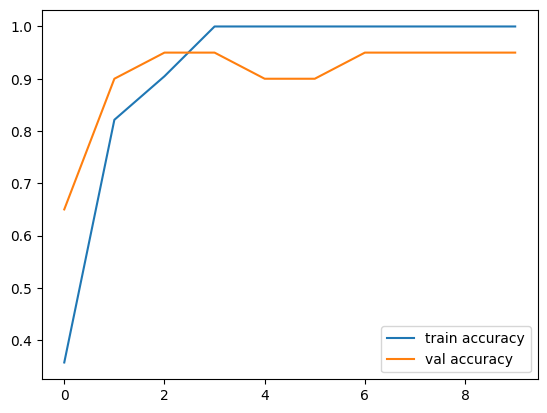

In [ ]:
# Ver resultados
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.show()

In [16]:
# Probar manualmente modelo
class_names = train_ds.class_names

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array)
    score = tf.nn.softmax(predictions[0])

    print("Predicción:", class_names[np.argmax(score)])
    print("Confianza:", 100 * np.max(score), "%")

In [17]:
predict_image("/content/drive/MyDrive/ProyectoIA-Ecomision/imagenes_prueba/Aprovechable_1.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicción: aprovechable
Confianza: 57.48559 %


In [ ]:
# Guardar modelo
model.save("/content/drive/MyDrive/ProyectoIA-Ecomision/modelo_ecomision.h5")

In [15]:
# Cargar modelo

model = load_model("/content/drive/MyDrive/ProyectoIA-Ecomision/modelo_ecomision.h5")